In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import PIL
import os
import pathlib

import tensorflow as tf
from tensorflow import keras
from keras import layers

import tensorflow_hub as hub

In [5]:
IMAGE_SHAPE= (224,224)     # pre trained model
classifier= keras.Sequential([
    hub.KerasLayer("https://tfhub.dev/google/tf2-preview/mobilenet_v2/classification/4", input_shape=IMAGE_SHAPE+(3,))
])

In [6]:
IMAGE_SHAPE+(3,)

(224, 224, 3)

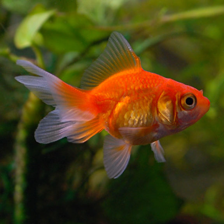

In [8]:
gold_fish= PIL.Image.open(r"C:\Users\PRATHEEK POOJARY\OneDrive\Desktop\Machine Learning\Datasets\goldfish.jpg").resize(IMAGE_SHAPE)
gold_fish

In [10]:
gold_fish= np.array(gold_fish)/255
gold_fish

array([[[0.28235294, 0.33333333, 0.07058824],
        [0.31372549, 0.37254902, 0.09019608],
        [0.34901961, 0.41960784, 0.11764706],
        ...,
        [0.32941176, 0.39215686, 0.00392157],
        [0.32156863, 0.38431373, 0.00392157],
        [0.30980392, 0.36862745, 0.        ]],

       [[0.28627451, 0.33333333, 0.08235294],
        [0.3254902 , 0.38039216, 0.10980392],
        [0.35294118, 0.42352941, 0.12941176],
        ...,
        [0.32156863, 0.38039216, 0.00392157],
        [0.31372549, 0.37254902, 0.00392157],
        [0.30196078, 0.36078431, 0.        ]],

       [[0.28627451, 0.33333333, 0.08627451],
        [0.31372549, 0.36862745, 0.10196078],
        [0.34509804, 0.41568627, 0.12941176],
        ...,
        [0.31764706, 0.37647059, 0.00392157],
        [0.30980392, 0.36862745, 0.00784314],
        [0.29803922, 0.35686275, 0.00392157]],

       ...,

       [[0.05490196, 0.10980392, 0.01568627],
        [0.05098039, 0.11372549, 0.01960784],
        [0.05098039, 0

In [12]:
gold_fish.shape

(224, 224, 3)

In [13]:
gold_fish[np.newaxis, ...].shape

(1, 224, 224, 3)

In [19]:
result= classifier.predict(gold_fish[np.newaxis, ...])
print(result)
result.shape

1/1 [==============================] - 0s 99ms/step
[[ 0.22101453  2.047488    9.622561   ... -1.4621583  -0.28146583
  -0.25984982]]


(1, 1001)

In [18]:
pred_label_index= np.argmax(result)
pred_label_index

2

load a flower dataset

In [21]:
dataset_url= "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir= tf.keras.utils.get_file('flower_photos',origin=dataset_url, 
                                  cache_dir= r"C:\Users\PRATHEEK POOJARY\OneDrive\Desktop\Machine Learning\Datasets", untar=True)
data_dir

'C:\\Users\\PRATHEEK POOJARY\\OneDrive\\Desktop\\Machine Learning\\Datasets\\datasets\\flower_photos'

In [22]:
data_dir= pathlib.Path(data_dir)
data_dir

WindowsPath('C:/Users/PRATHEEK POOJARY/OneDrive/Desktop/Machine Learning/Datasets/datasets/flower_photos')

In [25]:
list(data_dir.glob('*/*.jpg'))[0:5]

[WindowsPath('C:/Users/PRATHEEK POOJARY/OneDrive/Desktop/Machine Learning/Datasets/datasets/flower_photos/daisy/100080576_f52e8ee070_n.jpg'),
 WindowsPath('C:/Users/PRATHEEK POOJARY/OneDrive/Desktop/Machine Learning/Datasets/datasets/flower_photos/daisy/10140303196_b88d3d6cec.jpg'),
 WindowsPath('C:/Users/PRATHEEK POOJARY/OneDrive/Desktop/Machine Learning/Datasets/datasets/flower_photos/daisy/10172379554_b296050f82_n.jpg'),
 WindowsPath('C:/Users/PRATHEEK POOJARY/OneDrive/Desktop/Machine Learning/Datasets/datasets/flower_photos/daisy/10172567486_2748826a8b.jpg'),
 WindowsPath('C:/Users/PRATHEEK POOJARY/OneDrive/Desktop/Machine Learning/Datasets/datasets/flower_photos/daisy/10172636503_21bededa75_n.jpg')]

In [28]:
image_count= len(list(data_dir.glob('*/*.jpg')))
image_count

3670

In [34]:
roses= list(data_dir.glob('roses/*'))
roses

[WindowsPath('C:/Users/PRATHEEK POOJARY/OneDrive/Desktop/Machine Learning/Datasets/datasets/flower_photos/roses/10090824183_d02c613f10_m.jpg'),
 WindowsPath('C:/Users/PRATHEEK POOJARY/OneDrive/Desktop/Machine Learning/Datasets/datasets/flower_photos/roses/102501987_3cdb8e5394_n.jpg'),
 WindowsPath('C:/Users/PRATHEEK POOJARY/OneDrive/Desktop/Machine Learning/Datasets/datasets/flower_photos/roses/10503217854_e66a804309.jpg'),
 WindowsPath('C:/Users/PRATHEEK POOJARY/OneDrive/Desktop/Machine Learning/Datasets/datasets/flower_photos/roses/10894627425_ec76bbc757_n.jpg'),
 WindowsPath('C:/Users/PRATHEEK POOJARY/OneDrive/Desktop/Machine Learning/Datasets/datasets/flower_photos/roses/110472418_87b6a3aa98_m.jpg'),
 WindowsPath('C:/Users/PRATHEEK POOJARY/OneDrive/Desktop/Machine Learning/Datasets/datasets/flower_photos/roses/11102341464_508d558dfc_n.jpg'),
 WindowsPath('C:/Users/PRATHEEK POOJARY/OneDrive/Desktop/Machine Learning/Datasets/datasets/flower_photos/roses/11233672494_d8bf0a3dbf_n.jpg')

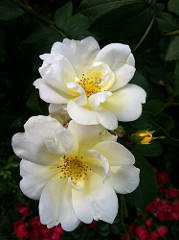

In [35]:
import PIL.Image


PIL.Image.open(roses[0])

In [36]:
flowers_image_dict={               #labeling the directory
    'roses': list(data_dir.glob('roses/*')),
    'daisy': list(data_dir.glob('daisy/*')),
    'dandelion': list(data_dir.glob('dandelion/*')),
    'sunflowers': list(data_dir.glob('sunflowers/*')),
    'tulips': list(data_dir.glob('tulips/*'))
}

In [37]:
flowers_label_dict={     #classs number 
    'roses': 0,
    'daisy': 1,
    'dandelion': 2,
    'sunflowers': 3,
    'tulips': 4,
}

In [60]:
x=[]
y=[]

for flower_name, image in flowers_image_dict.items():
    for image in image:
        img= cv2.imread(str(image))
        resized_img= cv2.resize(img,(224,224))
        x.append(resized_img)
        y.append(flowers_label_dict[flower_name])

In [61]:
x[0]

array([[[ 0, 15,  6],
        [ 0, 15,  6],
        [ 0, 16,  7],
        ...,
        [24, 51, 31],
        [25, 52, 32],
        [26, 53, 33]],

       [[ 8, 22, 14],
        [ 8, 22, 14],
        [ 7, 21, 14],
        ...,
        [21, 47, 31],
        [24, 49, 34],
        [25, 51, 35]],

       [[12, 22, 15],
        [12, 22, 15],
        [11, 22, 14],
        ...,
        [21, 43, 31],
        [24, 46, 33],
        [26, 48, 36]],

       ...,

       [[17, 29, 25],
        [14, 25, 20],
        [13, 22, 15],
        ...,
        [ 2, 11,  2],
        [ 0,  7,  1],
        [ 0,  4,  0]],

       [[19, 30, 28],
        [18, 28, 25],
        [16, 25, 19],
        ...,
        [ 2, 10,  2],
        [ 1,  8,  2],
        [ 0,  7,  2]],

       [[ 9, 19, 19],
        [15, 23, 22],
        [19, 27, 24],
        ...,
        [ 1, 11,  2],
        [ 2, 10,  3],
        [ 3, 11,  4]]], dtype=uint8)

In [62]:
x= np.array(x)
y= np.array(y)

In [63]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test= train_test_split(x, y, test_size=0.25, random_state=1)

In [68]:
x_train_scaled= x_train /255
x_test_scaled= x_test/255

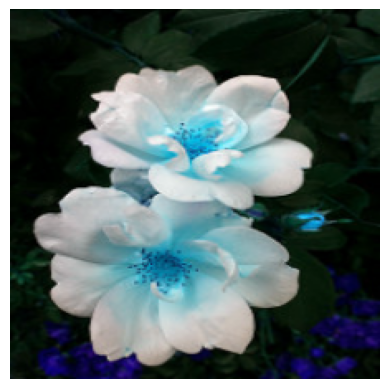

In [69]:
def show_image(index):
    plt.imshow(x[index])
    plt.axis('off')
show_image(0)

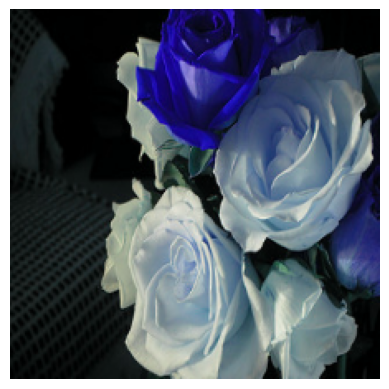

In [70]:
show_image(1)

In [71]:
x[0].shape


(224, 224, 3)

In [72]:
IMAGE_SHAPE+(3,)

(224, 224, 3)

In [73]:
x[0]= cv2.resize(x[0],IMAGE_SHAPE)
predicted = classifier.predict(np.array([x[0], x[1], x[2]]))
predicted = np.argmax(predicted, axis=1)
predicted

1/1 [==============================] - 1s 880ms/step


array([795, 880, 795], dtype=int64)

Now take pre-trained model and retrain it using flowers images

In [3]:
feature_extractor_model = "https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4"

pretrained_model_without_top_layer = hub.KerasLayer(
    feature_extractor_model, input_shape=(224, 224, 3), trainable=False)

In [4]:
num_of_flowers = 5

model = tf.keras.Sequential([
  pretrained_model_without_top_layer,
  tf.keras.layers.Dense(num_of_flowers)
])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 keras_layer (KerasLayer)    (None, 1280)              2257984   
                                                                 
 dense (Dense)               (None, 5)                 6405      
                                                                 
Total params: 2264389 (8.64 MB)
Trainable params: 6405 (25.02 KB)
Non-trainable params: 2257984 (8.61 MB)
_________________________________________________________________


In [ ]:
model.compile(
  optimizer="adam",
  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
  metrics=['acc'])

model.fit(x_train_scaled, y_train, epochs=5)

Epoch 1/5



86/86 [==============================] - 44s 461ms/step - loss: 0.7790 - acc: 0.7140
Epoch 2/5
86/86 [==============================] - 42s 487ms/step - loss: 0.4087 - acc: 0.8605
Epoch 3/5
86/86 [==============================] - 40s 465ms/step - loss: 0.3175 - acc: 0.8990
Epoch 4/5
86/86 [==============================] - 43s 505ms/step - loss: 0.2677 - acc: 0.9153
Epoch 5/5
86/86 [==============================] - 41s 476ms/step - loss: 0.2291 - acc: 0.9306


In [77]:
model.evaluate(x_test_scaled, y_test)

29/29 [==============================] - 15s 463ms/step - loss: 0.3734 - acc: 0.8693


[0.3733938932418823, 0.8692810535430908]